<a href="https://colab.research.google.com/github/dezurnyjkipia4/DataScince/blob/main/hw5/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#pip install kaggle
#https://www.kaggle.com/datasets/tahaberkterekli/bmw-cars-market-dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import KNNImputer

data = pd.read_csv("bmw.csv")
data.head() # посмотрим на данные

,car_id,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,body_type,color,owner_count,accident_history,service_history,country_sold
0,1,X5,2016,4.0,272,diesel,automatic,AWD,74655,8.9,196.0,66756,5,5,suv,white,2.0,no,partial,Netherlands
1,2,1 Series,2022,2.6,218,petrol,automatic,FWD,23469,8.4,190.0,26867,3,4,hatchback,black,1.0,no,partial,France
2,3,X1,2012,2.2,240,petrol,automatic,FWD,123273,7.8,174.0,31313,5,5,suv,white,3.0,no,full,Netherlands
3,4,X5,2022,3.8,316,diesel,NaN,AWD,33064,9.4,192.0,81594,5,5,suv,blue,1.0,no,NaN,France
4,5,7 Series,2023,3.1,294,petrol,automatic,RWD,23926,NaN,204.0,104105,4,5,sedan,white,1.0,no,full,Spain


In [3]:
#посчитаем пропущенные значения и в каких столбцах
missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print("Столбцы с пропущенными значениями и их количество:")
    print(missing_values)
else:
    print("Пропущенных значений нет ни в одном столбце.")

Столбцы с пропущенными значениями и их количество:
engine_size                     243
transmission                    215
fuel_consumption_l_per_100km    246
co2_emissions_g_km              225
color                           239
owner_count                     255
accident_history                254
service_history                 231
dtype: int64


In [4]:
df_cleaned = data.dropna()
print(f"Размер исходного датафрейма: {data.shape[0]} строк")
print(f"Размер очищенного датафрейма: {df_cleaned.shape[0]} строк")
df_cleaned.head()

Размер исходного датафрейма: 10000 строк
Размер очищенного датафрейма: 8238 строк


,car_id,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,body_type,color,owner_count,accident_history,service_history,country_sold
0,1,X5,2016,4.0,272,diesel,automatic,AWD,74655,8.9,196.0,66756,5,5,suv,white,2.0,no,partial,Netherlands
1,2,1 Series,2022,2.6,218,petrol,automatic,FWD,23469,8.4,190.0,26867,3,4,hatchback,black,1.0,no,partial,France
2,3,X1,2012,2.2,240,petrol,automatic,FWD,123273,7.8,174.0,31313,5,5,suv,white,3.0,no,full,Netherlands
5,6,X1,2010,1.9,190,diesel,automatic,AWD,182375,5.7,112.0,18615,5,5,suv,black,5.0,no,partial,France
6,7,5 Series,2008,4.2,383,petrol,automatic,AWD,274131,10.7,222.0,27173,4,5,sedan,blue,4.0,yes,partial,USA


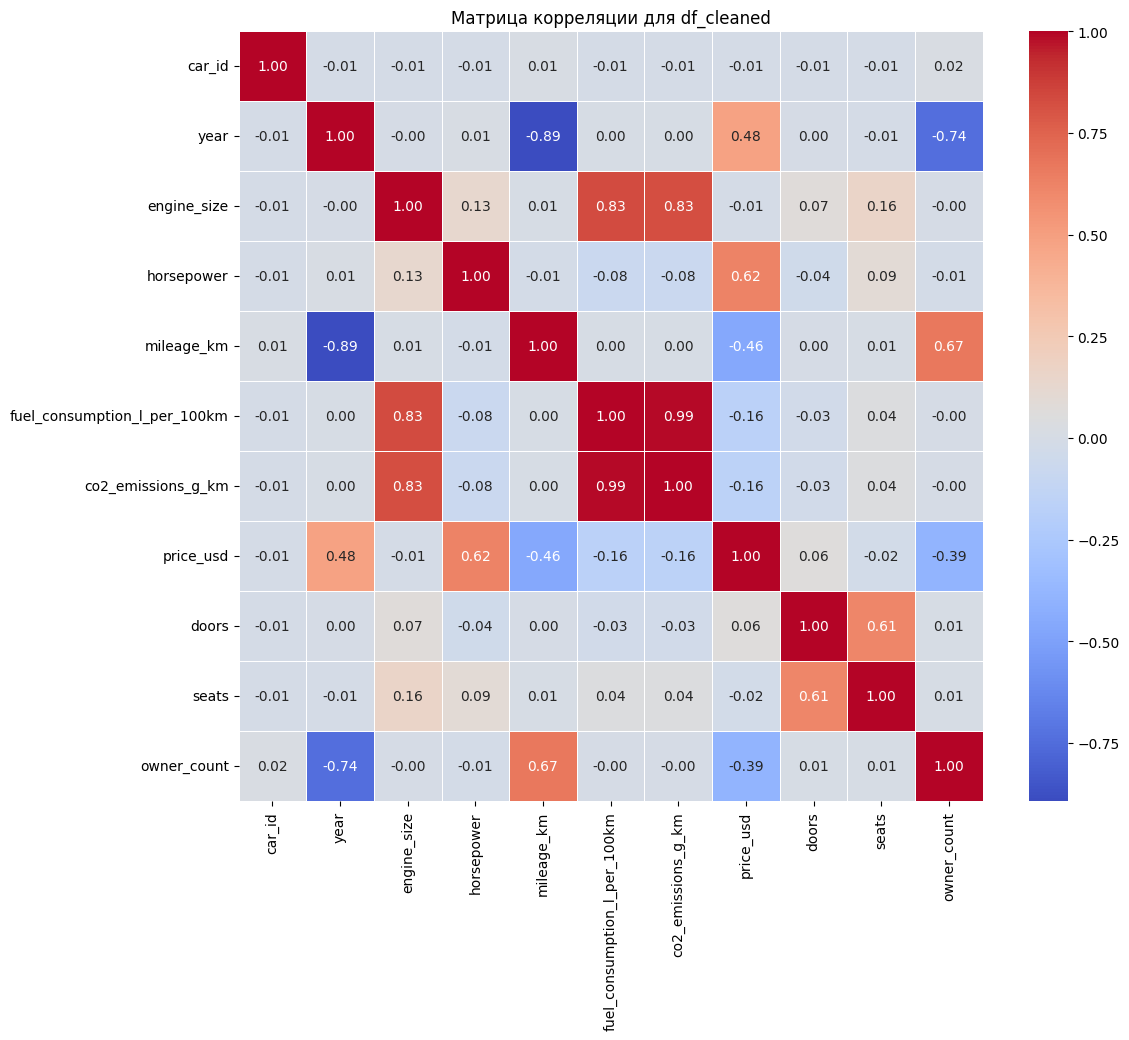

In [5]:
# построение матрицы корреляции
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

correlation_matrix = df_cleaned.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Матрица корреляции для df_cleaned')
plt.show()

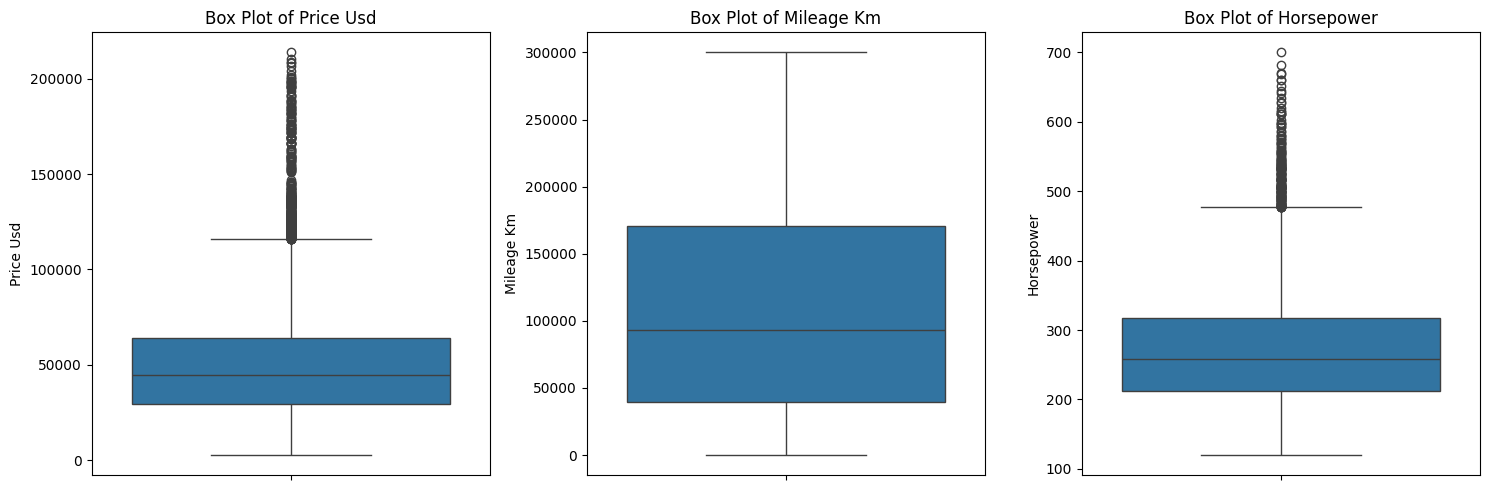

In [8]:
#Диаграммы размаха для ключевых числовых столбцов (price_usd, mileage_km, horsepower), чтобы выявить выбросы.

plt.figure(figsize=(15, 5))
for i, col in enumerate(columns_to_plot):
    plt.subplot(1, 3, i + 1) # Create subplots for better layout
    sns.boxplot(y=df_cleaned[col])
    plt.title(f'Box Plot of {col.replace("_", " ").title()}') # Dynamic title generation
    plt.ylabel(col.replace("_", " ").title())

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [9]:
#Выявление выбросов с помощью метода межквартильного размаха
columns_for_iqr = ['price_usd', 'mileage_km', 'horsepower']

print("Calculating IQR and outlier bounds:")
for col in columns_for_iqr:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nColumn: {col}")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}")
    print(f"  Upper Bound: {upper_bound:.2f}")

Calculating IQR and outlier bounds:

Column: price_usd
  Q1: 29351.75
  Q3: 63914.25
  IQR: 34562.50
  Lower Bound: -22492.00
  Upper Bound: 115758.00

Column: mileage_km
  Q1: 39308.50
  Q3: 170802.50
  IQR: 131494.00
  Lower Bound: -157932.50
  Upper Bound: 368043.50

Column: horsepower
  Q1: 212.00
  Q3: 318.00
  IQR: 106.00
  Lower Bound: 53.00
  Upper Bound: 477.00


In [10]:
#Фильтрация строк, в которых значения выходят за пределы рассчитанных нижней и верхней границ и сохранение в  df_no_outliers
df_no_outliers = df_cleaned.copy()

print(f"Shape of DataFrame before outlier removal: {df_cleaned.shape}")

for col in columns_for_iqr:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower_bound) & (df_no_outliers[col] <= upper_bound)]

print(f"Shape of DataFrame after outlier removal: {df_no_outliers.shape}")

Shape of DataFrame before outlier removal: (8238, 20)
Shape of DataFrame after outlier removal: (7769, 20)


**Reasoning**:
To visually confirm the impact of outlier removal, I will create box plots for the `price_usd`, `mileage_km`, and `horsepower` columns from the `df_no_outliers` DataFrame.



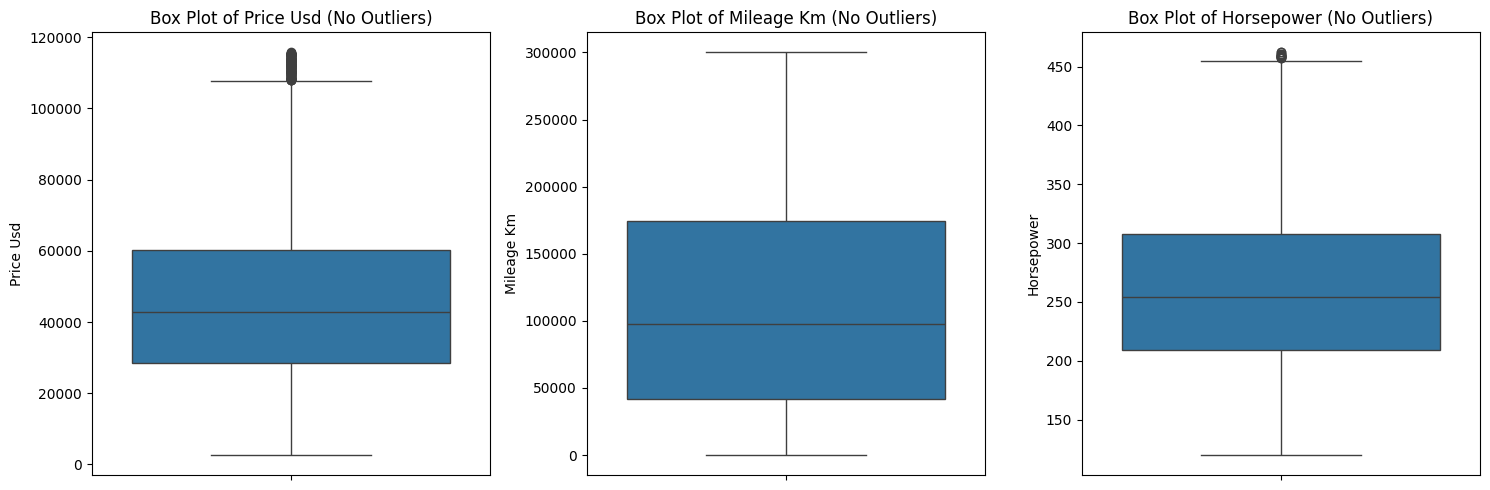

In [12]:
#диаграммы размаха для столбцов price_usd, mileage_km и horsepower в DataFrame df_no_outliers
plt.figure(figsize=(15, 5))
for i, col in enumerate(columns_for_iqr):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df_no_outliers[col])
    plt.title(f'Box Plot of {col.replace("_", " ").title()} (No Outliers)')
    plt.ylabel(col.replace("_", " ").title())

plt.tight_layout()
plt.show()
# С помощью метода межквартильного размаха были выявлены и удалены 469 строк (примерно 5,7 % исходных данных) как выбросы.
# Форма DataFrame изменилась с (8238, 20) до удаления выбросов на (7769, 20) после удаления.
# Ящики с усами, построенные после удаления выбросов, визуально подтвердили отсутствие экстремальных выбросов в price_usd, mileage_km и лошадиных силах, что указывает на более равномерное распределение данных.